# 02b RC2 Reduction — Panel Size vs Accuracy

Starting from the **Union top-500 set (1005 unique SNPs)** — the best-performing condition
in RC2 ML (~99% accuracy with SVM/LR) — this notebook asks:

> *How many SNPs can we remove while keeping accuracy high?*

SNPs are ranked by the RF + LR combined importance already computed in `02b_rc2_ml_training`.  
For each panel size, all 10 classifiers are re-evaluated with 5-fold stratified CV.

In [1]:
import sys
from pathlib import Path
_r = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts' / 'config.py').exists())
sys.path.insert(0, str(_r / 'scripts'))
from notebook_init import setup
cfg, PATHS, POPULATIONS, HARD_FILTERS, SITUATIONAL_FILTERS, ML = setup()
import os, time
print(f'Working directory: {os.getcwd()}')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

print('All imports OK')

Project root : /home/ibmelab/Projects/AISNP_Research
genomes_data : /mnt/data/aisnp_data/1000genomes/
output root  : output
Working directory: /home/ibmelab/Projects/AISNP_Research
All imports OK


## Step 1: Load Genotype Matrix and Feature Importance Ranking

In [2]:
numpy_cache  = str(PATHS.GENOTYPE_MATRIX)
cols_cache   = str(PATHS.GENOTYPE_MATRIX_COLS)
prefix_05a   = str(PATHS.outputs_dir('statistical/05a_stat_training'))
imp_path     = f"{prefix_05a}_feature_importance.csv"
SAMPLES_CSV  = str(PATHS.SAMPLES_CSV)

for p in [numpy_cache, cols_cache, imp_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'Required file missing: {p}')

# Genotype matrix
print('Loading genotype matrix...')
t0 = time.time()
data = np.load(numpy_cache)
G_raw        = data['G']                          # (n_samples, n_snps), int8
sample_names = list(data['samples'].astype(str))
with open(cols_cache) as f:
    all_snp_ids = [l.strip() for l in f]
snp_index = {s: i for i, s in enumerate(all_snp_ids)}
print(f'Matrix loaded in {time.time()-t0:.1f}s  |  shape: {G_raw.shape}')

# Population labels
samples_df = pd.read_csv(SAMPLES_CSV, header=None, names=['sample','pop','super_pop'])
pop_lookup  = dict(zip(samples_df['sample'], samples_df['pop']))
pop_labels  = np.array([pop_lookup.get(s, 'UNK') for s in sample_names])
le  = LabelEncoder()
y   = pop_labels
y_enc = le.fit_transform(y)
print(f'Classes: {le.classes_}  |  dist: {dict(zip(*np.unique(y, return_counts=True)))}')

# Feature importance ranking from 05a (union-500 = 1005 SNPs).
# 05a ranks by LR coefficient (the chosen reductor) and writes the file already
# sorted best-first; sort by rank_lr defensively in case of an older file.
imp_df = pd.read_csv(imp_path)
sort_col = 'rank_lr' if 'rank_lr' in imp_df.columns else imp_df.columns[-2]
imp_df = imp_df.sort_values(sort_col)
ranked_snps = imp_df['snp_id'].tolist()   # ordered best → worst (LR rank)
print(f'\nFeature importance ranking: {len(ranked_snps)} SNPs (union top-500 set, LR-ranked)')
print(f'Source breakdown:')
print(imp_df['source'].value_counts().to_string())

Loading genotype matrix...
Matrix loaded in 0.8s  |  shape: (504, 614759)
Classes: ['CN' 'JPT' 'SEA']  |  dist: {np.str_('CN'): np.int64(208), np.str_('JPT'): np.int64(104), np.str_('SEA'): np.int64(192)}

Feature importance ranking: 1005 SNPs (union top-500 set, LR-ranked)
Source breakdown:
source
afd             362
chi2+jsd        287
chi2            143
jsd              75
chi2+jsd+afd     70
jsd+afd          68


## Step 2: Define Panel Sizes and Classifiers

In [3]:
# Fine grid (for cross-path comparison) + larger sizes (for the V2 elbow analysis)
PANEL_SIZES = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100,
               150, 200, 300, 500, 750, len(ranked_snps)]

# 6-classifier set, matched across ALL pipeline paths for a fair cross-path comparison
classifiers = {
    'Random Forest':     RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost':           XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0),
    'Logistic Reg':      LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', n_jobs=-1),
    'SVM (RBF)':         SVC(kernel='rbf',    random_state=42, probability=True),   # probability=True for ROC-AUC
    'SVM (Linear)':      SVC(kernel='linear', random_state=42, probability=True),
    'Grad Boosting':     GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
}
NEEDS_SCALE = {'Logistic Reg', 'SVM (RBF)', 'SVM (Linear)'}
NEEDS_ENC   = {'XGBoost'}

# Two reductor rankings from 05a feature_importance.csv
rf_order = imp_df.sort_values('rank_rf')['snp_id'].tolist()
lr_order = imp_df.sort_values('rank_lr')['snp_id'].tolist()
REDUCTORS = {'LR': lr_order, 'RF': rf_order}   # LR is the V2 primary (used for elbow/PCA)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'f1': 'f1_weighted', 'roc_auc': 'roc_auc_ovr', 'mcc': 'matthews_corrcoef'}

# RF reductor only needs the fine grid (≤100) for the comparison; LR runs the full
# grid (incl. large sizes) because the elbow/PCA analysis uses the LR ranking.
FINE_MAX = 100
print(f'Panel sizes: {PANEL_SIZES}')
print(f'Reductors: {list(REDUCTORS)}  |  Classifiers: {len(classifiers)}')
print(f'LR runs all sizes; RF runs sizes ≤ {FINE_MAX} (for cross-path comparison only)')

Panel sizes: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100, 150, 200, 300, 500, 750, 1005]
Reductors: ['LR', 'RF']  |  Classifiers: 6
LR runs all sizes; RF runs sizes ≤ 100 (for cross-path comparison only)


## Step 3: Run Reduction Experiment

In [4]:
all_results = []
total = len(PANEL_SIZES) * len(classifiers) + len([s for s in PANEL_SIZES if s <= FINE_MAX]) * len(classifiers)
done  = 0

for reductor, order in REDUCTORS.items():
    sizes = PANEL_SIZES if reductor == 'LR' else [s for s in PANEL_SIZES if s <= FINE_MAX]
    for panel_size in sizes:
        snp_subset = order[:panel_size]
        idx = [snp_index[s] for s in snp_subset if s in snp_index]
        actual_n = len(idx)

        X_panel  = G_raw[:, idx].astype(np.float32)
        X_scaled = StandardScaler().fit_transform(X_panel)

        print(f'\n── [{reductor}] Panel size {panel_size:4d}  ({actual_n} in matrix) ──')

        for clf_name, clf in classifiers.items():
            X_use = X_scaled if clf_name in NEEDS_SCALE else X_panel
            y_use = y_enc   if clf_name in NEEDS_ENC   else y

            try:
                scores = cross_validate(clf, X_use, y_use, cv=cv, scoring=scoring,
                                        return_train_score=True, n_jobs=1)
                row = {
                    'reductor':     reductor,
                    'panel_size':   panel_size,
                    'actual_n':     actual_n,
                    'classifier':   clf_name,
                    'acc_mean':     scores['test_accuracy'].mean(),
                    'acc_std':      scores['test_accuracy'].std(),
                    'f1_mean':      scores['test_f1'].mean(),
                    'f1_std':       scores['test_f1'].std(),
                    'roc_auc_mean': scores['test_roc_auc'].mean() if 'test_roc_auc' in scores else np.nan,
                    'roc_auc_std':  scores['test_roc_auc'].std()  if 'test_roc_auc' in scores else np.nan,
                    'mcc_mean':     scores['test_mcc'].mean(),
                    'mcc_std':      scores['test_mcc'].std(),
                    'train_acc':    scores['train_accuracy'].mean(),
                    'overfit_gap':  scores['train_accuracy'].mean() - scores['test_accuracy'].mean(),
                }
            except Exception as e:
                row = {'reductor': reductor, 'panel_size': panel_size, 'actual_n': actual_n,
                       'classifier': clf_name, 'acc_mean': np.nan, 'acc_std': np.nan,
                       'f1_mean': np.nan, 'f1_std': np.nan,
                       'roc_auc_mean': np.nan, 'roc_auc_std': np.nan,
                       'mcc_mean': np.nan, 'mcc_std': np.nan,
                       'train_acc': np.nan, 'overfit_gap': np.nan}

            all_results.append(row)
            done += 1
            print(f'  {clf_name:20s}  acc={row["acc_mean"]:.4f}  '
                  f'f1={row["f1_mean"]:.4f}  roc={row["roc_auc_mean"]:.4f}  [{done}/{total}]')

results_full = pd.DataFrame(all_results)   # both reductors (RF only ≤100)
print(f'\nDone. {len(results_full)} rows  (LR + RF).')


── [LR] Panel size    5  (5 in matrix) ──
  Random Forest         acc=0.6805  f1=0.6602  roc=0.8028  [1/252]
  XGBoost               acc=0.6925  f1=0.6713  roc=0.8062  [2/252]
  Logistic Reg          acc=0.6905  f1=0.6695  roc=0.8172  [3/252]
  SVM (RBF)             acc=0.6825  f1=0.6626  roc=0.7975  [4/252]
  SVM (Linear)          acc=0.6885  f1=0.6677  roc=0.8169  [5/252]
  Grad Boosting         acc=0.6924  f1=0.6725  roc=0.7995  [6/252]

── [LR] Panel size   10  (10 in matrix) ──
  Random Forest         acc=0.7480  f1=0.7437  roc=0.8840  [7/252]
  XGBoost               acc=0.7400  f1=0.7386  roc=0.8934  [8/252]
  Logistic Reg          acc=0.7878  f1=0.7851  roc=0.9211  [9/252]
  SVM (RBF)             acc=0.7917  f1=0.7844  roc=0.9014  [10/252]
  SVM (Linear)          acc=0.7779  f1=0.7752  roc=0.9148  [11/252]
  Grad Boosting         acc=0.7401  f1=0.7382  roc=0.8705  [12/252]

── [LR] Panel size   15  (15 in matrix) ──
  Random Forest         acc=0.8116  f1=0.8082  roc=0.9370  [13

## Step 4: Summary Tables

In [5]:
# The elbow / PCA / confusion-matrix analysis below uses the LR reductor (V2 primary).
# `results_full` keeps both reductors (for the cross-path reductor_sweep.csv saved later).
results_df = results_full[results_full['reductor'] == 'LR'].copy()

# Best accuracy per panel size (max over classifiers)
best_df = (
    results_df.sort_values('acc_mean', ascending=False)
    .groupby('panel_size')
    .first()
    .reset_index()
    [['panel_size', 'actual_n', 'classifier', 'acc_mean', 'acc_std',
      'f1_mean', 'roc_auc_mean', 'mcc_mean', 'overfit_gap']]
    .sort_values('panel_size')
)

# Accuracy at full set (baseline)
baseline_acc = best_df[best_df['panel_size'] == len(ranked_snps)]['acc_mean'].values[0]
best_df['acc_drop'] = baseline_acc - best_df['acc_mean']
best_df['pct_retained'] = (best_df['acc_mean'] / baseline_acc * 100).round(2)

print('Best classifier per panel size (LR reductor):')
print('=' * 100)
display(best_df.to_string(index=False))

# Pivot: all classifiers × panel sizes
pivot = results_df.pivot(index='classifier', columns='panel_size', values='acc_mean')
print('\nAll classifiers × panel sizes (LR reductor):')
display(pivot.round(4))

Best classifier per panel size (LR reductor):


' panel_size  actual_n   classifier  acc_mean  acc_std  f1_mean  roc_auc_mean  mcc_mean  overfit_gap  acc_drop  pct_retained\n          5         5      XGBoost  0.692455 0.026595 0.671257      0.806238  0.515793     0.014389  0.297624         69.94\n         10        10    SVM (RBF)  0.791703 0.020420 0.784440      0.901408  0.673952     0.048578  0.198376         79.96\n         15        15    SVM (RBF)  0.835366 0.017979 0.829467      0.948686  0.745977     0.087750  0.154713         84.37\n         20        20    SVM (RBF)  0.875089 0.033274 0.873135      0.961612  0.807943     0.069356  0.114990         88.39\n         25        25    SVM (RBF)  0.884970 0.014510 0.882167      0.974188  0.821342     0.078325  0.105109         89.38\n         30        30 Logistic Reg  0.906812 0.026119 0.906025      0.978210  0.854908     0.040112  0.083267         91.59\n         35        35 Logistic Reg  0.906772 0.020282 0.906065      0.978468  0.854638     0.050076  0.083307         91.59\


All classifiers × panel sizes (LR reductor):


panel_size,5,10,15,20,25,30,35,40,45,50,...,75,80,90,100,150,200,300,500,750,1005
classifier,,,,,,,,,,,,,,,,,,,,,
Grad Boosting,0.6924,0.7401,0.7877,0.8155,0.8491,0.8631,0.8690,0.8671,0.8909,0.8969,...,0.9008,0.9227,0.9167,0.9187,0.9265,0.9385,0.9504,0.9385,0.9305,0.9325
Logistic Reg,0.6905,0.7878,0.8294,0.8631,0.8730,0.9068,0.9068,0.9048,0.9207,0.9128,...,0.9385,0.9484,0.9603,0.9683,0.9861,0.9941,0.9980,1.0000,0.9960,0.9901
Random Forest,0.6805,0.7480,0.8116,0.8314,0.8830,0.8909,0.8889,0.9048,0.9029,0.9167,...,0.9346,0.9286,0.9386,0.9425,0.9603,0.9683,0.9702,0.9722,0.9623,0.9682
SVM (Linear),0.6885,0.7779,0.8175,0.8552,0.8691,0.8870,0.8988,0.9048,0.9147,0.9048,...,0.9346,0.9465,0.9464,0.9682,0.9881,1.0000,1.0000,1.0000,0.9960,0.9901
SVM (RBF),0.6825,0.7917,0.8354,0.8751,0.8850,0.9028,0.9048,0.9127,0.9246,0.9385,...,0.9584,0.9643,0.9663,0.9822,0.9940,0.9980,1.0000,1.0000,0.9960,0.9901
XGBoost,0.6925,0.7400,0.8115,0.8374,0.8571,0.8769,0.8829,0.8869,0.8929,0.8969,...,0.9048,0.9028,0.9028,0.9048,0.9365,0.9325,0.9245,0.9305,0.9245,0.9325


## Step 5: Visualisations

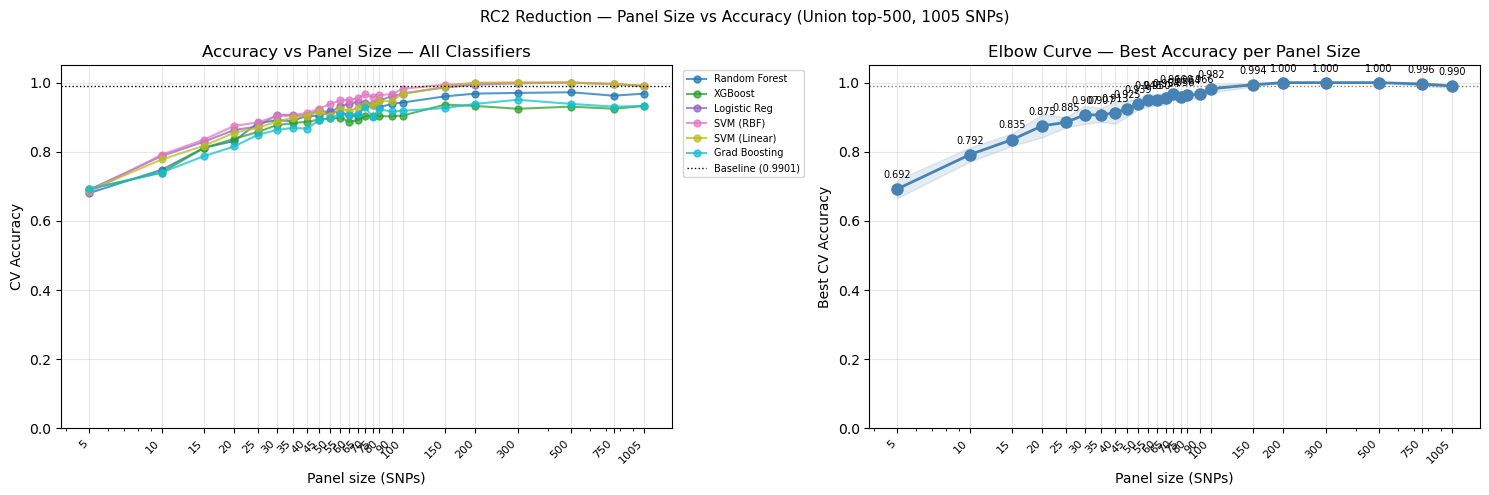

In [6]:
output_prefix = str(PATHS.outputs_dir("statistical/05b_reduction"))
pop_colors    = {'CN': '#e41a1c', 'JPT': '#377eb8', 'SEA': '#4daf4a'}

# ── Elbow curve ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: all classifiers
ax = axes[0]
cmap = plt.cm.tab10(np.linspace(0, 1, len(classifiers)))
for color, clf_name in zip(cmap, classifiers):
    sub = results_df[results_df['classifier'] == clf_name].sort_values('panel_size')
    ax.plot(sub['panel_size'], sub['acc_mean'], 'o-', color=color,
            label=clf_name, alpha=0.75, linewidth=1.5, markersize=5)
ax.axhline(baseline_acc, color='black', linestyle=':', linewidth=1, label=f'Baseline ({baseline_acc:.4f})')
ax.set_xlabel('Panel size (SNPs)')
ax.set_ylabel('CV Accuracy')
ax.set_title('Accuracy vs Panel Size — All Classifiers')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks(PANEL_SIZES)
ax.set_xticklabels(PANEL_SIZES, rotation=45, ha='right', fontsize=8)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

# Right: best classifier per size + accuracy drop
ax2 = axes[1]
ax2.plot(best_df['panel_size'], best_df['acc_mean'], 'o-',
         color='steelblue', linewidth=2, markersize=8, label='Best acc')
ax2.fill_between(best_df['panel_size'],
                 best_df['acc_mean'] - best_df['acc_std'],
                 best_df['acc_mean'] + best_df['acc_std'],
                 alpha=0.15, color='steelblue')
ax2.axhline(baseline_acc, color='gray', linestyle=':', linewidth=1)

# Annotate each point with best classifier name + acc
for _, row in best_df.iterrows():
    ax2.annotate(f"{row['acc_mean']:.3f}",
                 (row['panel_size'], row['acc_mean']),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=7)

ax2.set_xlabel('Panel size (SNPs)')
ax2.set_ylabel('Best CV Accuracy')
ax2.set_title('Elbow Curve — Best Accuracy per Panel Size')
ax2.set_xscale('log')
ax2.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax2.set_xticks(PANEL_SIZES)
ax2.set_xticklabels(PANEL_SIZES, rotation=45, ha='right', fontsize=8)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.suptitle('RC2 Reduction — Panel Size vs Accuracy (Union top-500, 1005 SNPs)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{output_prefix}_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

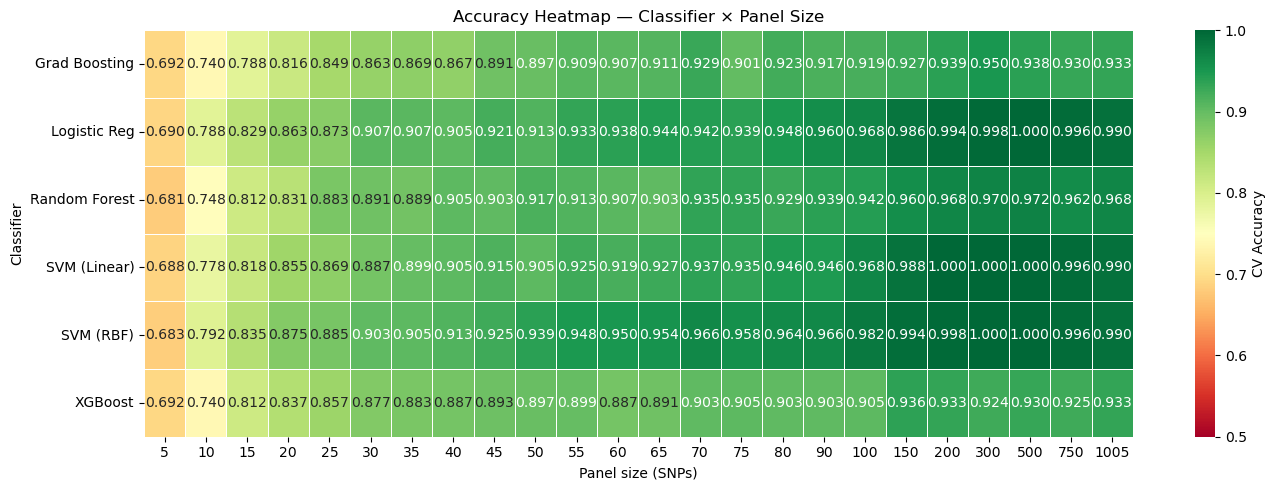

In [7]:
# ── Heatmap: classifier × panel size ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot.round(3), annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'CV Accuracy'})
ax.set_title('Accuracy Heatmap — Classifier × Panel Size')
ax.set_xlabel('Panel size (SNPs)')
ax.set_ylabel('Classifier')
plt.tight_layout()
plt.savefig(f'{output_prefix}_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

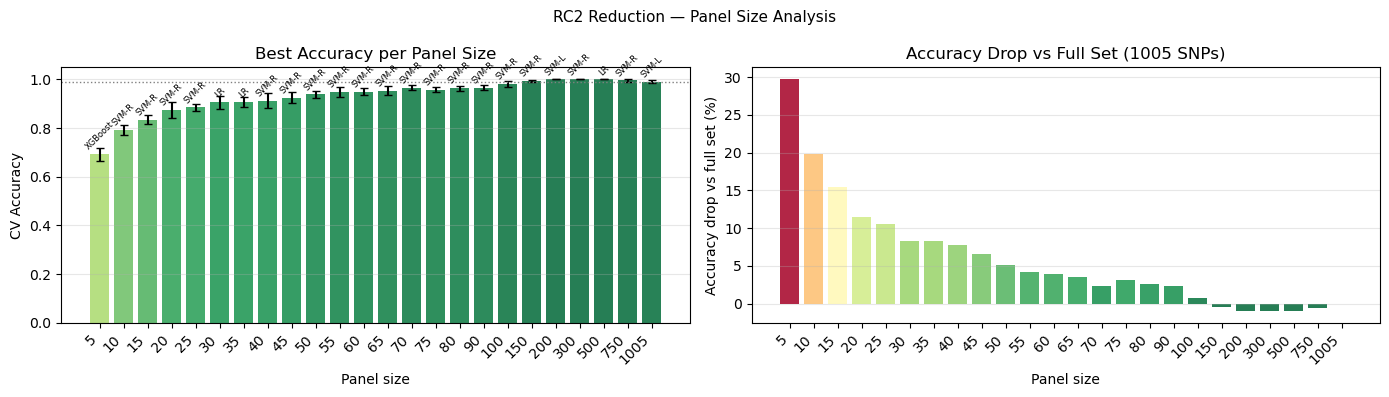

In [8]:
# ── Accuracy drop bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
colors = plt.cm.RdYlGn(best_df['acc_mean'].values)
bars = ax.bar(range(len(best_df)), best_df['acc_mean'], color=colors, alpha=0.85,
              yerr=best_df['acc_std'], capsize=3)
ax.set_xticks(range(len(best_df)))
ax.set_xticklabels(best_df['panel_size'].astype(str), rotation=45, ha='right')
ax.set_xlabel('Panel size')
ax.set_ylabel('CV Accuracy')
ax.set_title('Best Accuracy per Panel Size')
ax.set_ylim(0, 1.05)
ax.axhline(baseline_acc, color='gray', linestyle=':', linewidth=1)
ax.grid(alpha=0.3, axis='y')
for bar, row in zip(bars, best_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            row.classifier.replace('Logistic Reg','LR').replace('SVM (Linear)','SVM-L')
                          .replace('SVM (RBF)','SVM-R').replace('Random Forest','RF'),
            ha='center', va='bottom', fontsize=6, rotation=45)

ax2 = axes[1]
drop_colors = plt.cm.RdYlGn_r(best_df['acc_drop'].values / best_df['acc_drop'].max().clip(0.01))
ax2.bar(range(len(best_df)), best_df['acc_drop'] * 100, color=drop_colors, alpha=0.85)
ax2.set_xticks(range(len(best_df)))
ax2.set_xticklabels(best_df['panel_size'].astype(str), rotation=45, ha='right')
ax2.set_xlabel('Panel size')
ax2.set_ylabel('Accuracy drop vs full set (%)')
ax2.set_title(f'Accuracy Drop vs Full Set ({len(ranked_snps)} SNPs)')
ax2.grid(alpha=0.3, axis='y')

plt.suptitle('RC2 Reduction — Panel Size Analysis', fontsize=11)
plt.tight_layout()
plt.savefig(f'{output_prefix}_accuracy_drop.png', dpi=150, bbox_inches='tight')
plt.show()

Elbow point (acc drop ≤ 2%): 100 SNPs  (acc=0.9822, drop=0.0079)


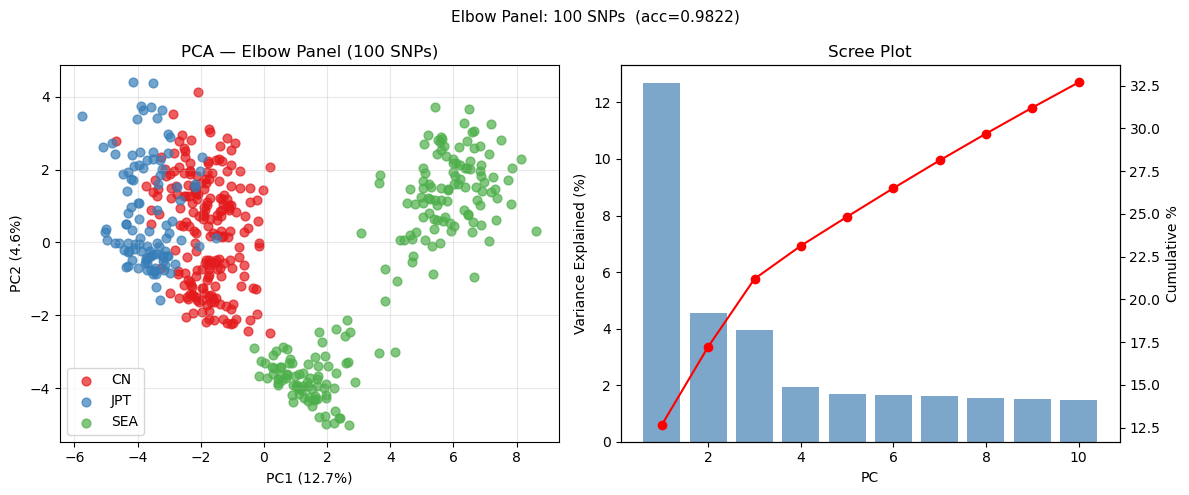

In [9]:
# ── PCA at elbow point ────────────────────────────────────────────────────────
# Use the smallest panel size that keeps accuracy within 2% of baseline
elbow_row = best_df[best_df['acc_drop'] <= 0.02].iloc[0]
elbow_n   = int(elbow_row['panel_size'])
print(f"Elbow point (acc drop ≤ 2%): {elbow_n} SNPs  "
      f"(acc={elbow_row['acc_mean']:.4f}, drop={elbow_row['acc_drop']:.4f})")

elbow_snps = ranked_snps[:elbow_n]
elbow_idx  = [snp_index[s] for s in elbow_snps if s in snp_index]
X_elbow    = G_raw[:, elbow_idx].astype(np.float32)
X_elbow_sc = StandardScaler().fit_transform(X_elbow)

n_pca = min(10, X_elbow.shape[1])
pca   = PCA(n_components=n_pca)
X_pca = pca.fit_transform(X_elbow_sc)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pop_plot_colors = {'CN': '#e41a1c', 'JPT': '#377eb8', 'SEA': '#4daf4a'}
for pop in le.classes_:
    mask = y == pop
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=pop_plot_colors.get(pop, 'gray'), label=pop, alpha=0.7, s=40)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'PCA — Elbow Panel ({elbow_n} SNPs)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(range(1, n_pca+1), pca.explained_variance_ratio_*100, color='steelblue', alpha=0.7)
ax2 = axes[1].twinx()
ax2.plot(range(1, n_pca+1), np.cumsum(pca.explained_variance_ratio_)*100, 'r-o')
ax2.set_ylabel('Cumulative %')
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Scree Plot')

plt.suptitle(f'Elbow Panel: {elbow_n} SNPs  (acc={elbow_row["acc_mean"]:.4f})', fontsize=11)
plt.tight_layout()
plt.savefig(f'{output_prefix}_pca_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5b: Confusion Matrices — Best Model at Each Panel Size

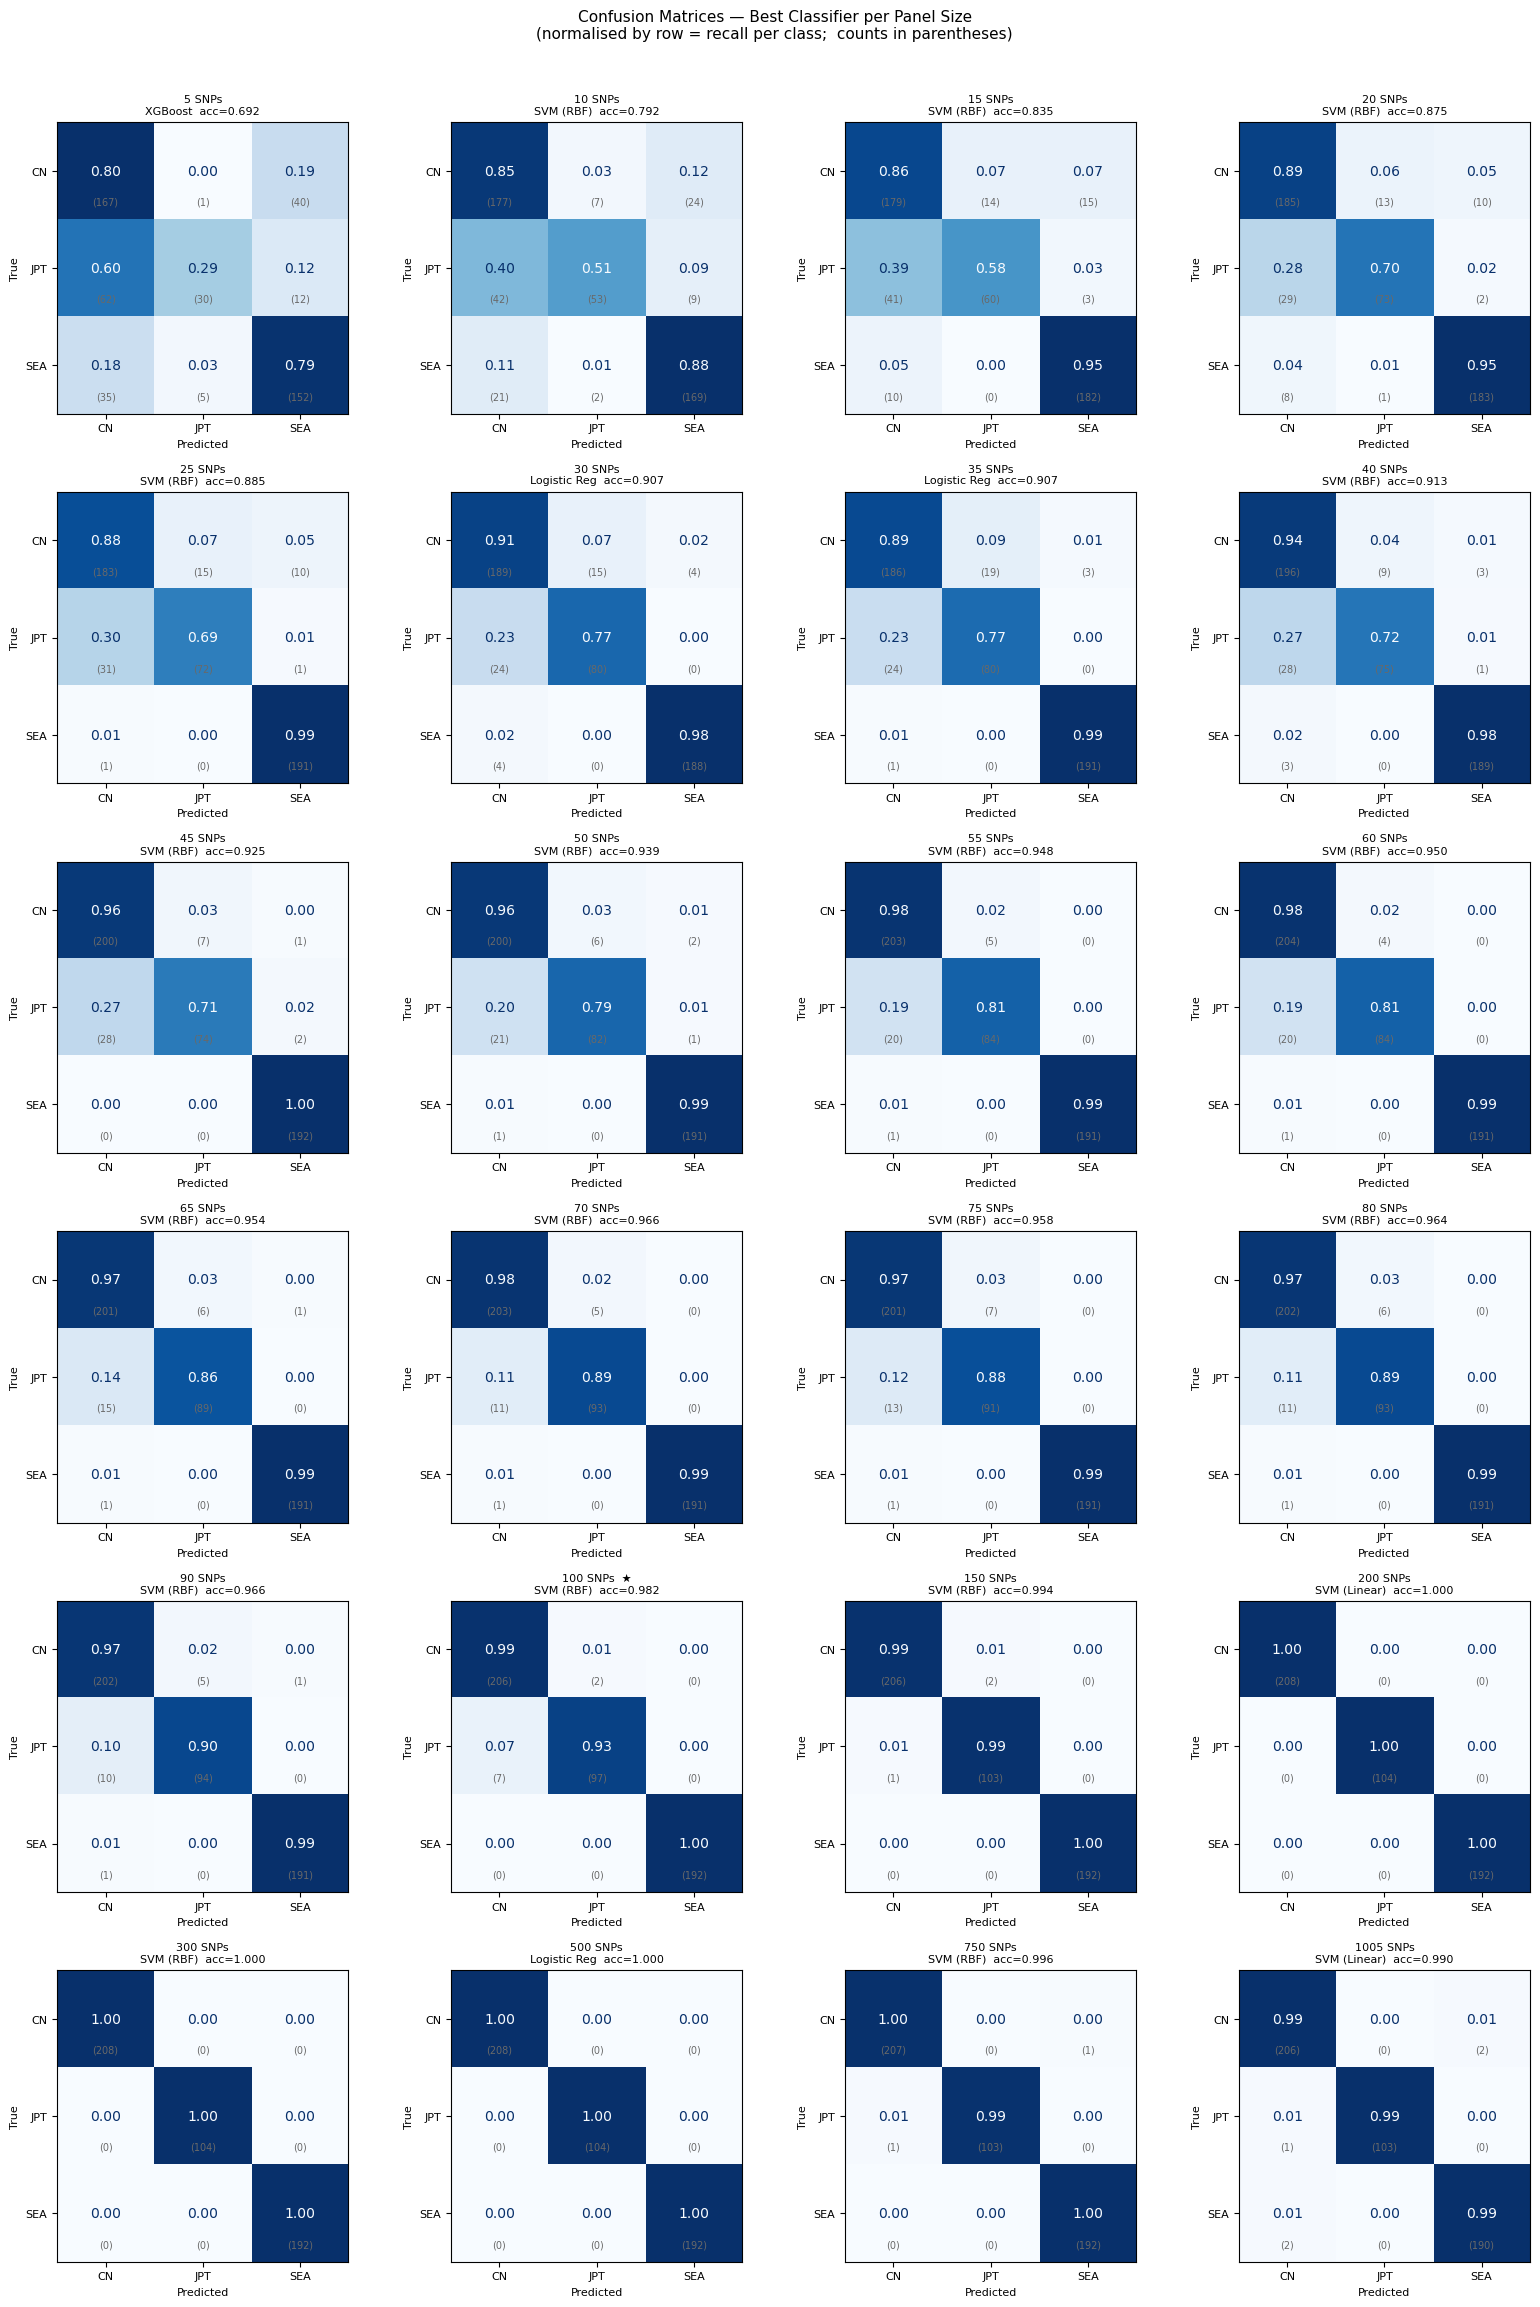

Confusion matrices saved.


In [10]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

n_sizes  = len(PANEL_SIZES)
n_cols   = 4
n_rows   = int(np.ceil(n_sizes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 4, n_rows * 3.8))
axes = axes.flatten()

class_labels = le.classes_

for ax_idx, panel_size in enumerate(PANEL_SIZES):
    ax = axes[ax_idx]

    # Best classifier for this panel size
    best_clf_name = best_df[best_df['panel_size'] == panel_size]['classifier'].values[0]
    best_acc      = best_df[best_df['panel_size'] == panel_size]['acc_mean'].values[0]
    clf           = classifiers[best_clf_name].__class__(
                        **classifiers[best_clf_name].get_params()
                    )

    # Build feature matrix
    snp_subset = ranked_snps[:panel_size]
    idx        = [snp_index[s] for s in snp_subset if s in snp_index]
    X_panel    = G_raw[:, idx].astype(np.float32)
    X_scaled   = StandardScaler().fit_transform(X_panel)

    X_use = X_scaled if best_clf_name in NEEDS_SCALE else X_panel
    y_use = y_enc   if best_clf_name in NEEDS_ENC   else y

    # OOF predictions via cross_val_predict
    y_pred = cross_val_predict(clf, X_use, y_use, cv=cv)

    # Decode if integer-encoded
    if best_clf_name in NEEDS_ENC:
        y_true_labels = le.inverse_transform(y_use)
        y_pred_labels = le.inverse_transform(y_pred)
    else:
        y_true_labels = y_use
        y_pred_labels = y_pred

    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=class_labels)

    # Normalise row-wise so colours reflect per-class recall
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')

    # Overlay raw counts in parentheses
    for i in range(len(class_labels)):
        for j in range(len(class_labels)):
            ax.text(j, i + 0.32, f'({cm[i,j]})',
                    ha='center', va='center', fontsize=7, color='dimgray')

    flag = '  ★' if panel_size == elbow_n else ''
    ax.set_title(
        f'{panel_size} SNPs{flag}\n'
        f'{best_clf_name}  acc={best_acc:.3f}',
        fontsize=8
    )
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(labelsize=8)

# Hide unused axes
for ax_idx in range(n_sizes, len(axes)):
    axes[ax_idx].set_visible(False)

plt.suptitle(
    'Confusion Matrices — Best Classifier per Panel Size\n'
    '(normalised by row = recall per class;  counts in parentheses)',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(f'{output_prefix}_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved.')

## Step 6: Save Results and Final SNP Panel

In [11]:
results_df.to_csv(f'{output_prefix}_all_cv_results.csv', index=False)
print(f'Saved: {output_prefix}_all_cv_results.csv  (LR reductor)')

# Dual-reductor fine-grid table for the cross-path comparison (06 section 5d)
reductor_sweep_df = (results_full[results_full['panel_size'] <= FINE_MAX]
                     [['reductor', 'panel_size', 'classifier', 'acc_mean', 'acc_std',
                       'f1_mean', 'mcc_mean', 'roc_auc_mean']]
                     .rename(columns={'panel_size': 'n_snps'}))
reductor_sweep_df.to_csv(f'{output_prefix}_reductor_sweep.csv', index=False)
print(f'Saved: {output_prefix}_reductor_sweep.csv  {reductor_sweep_df.shape}  (RF + LR)')

best_df.to_csv(f'{output_prefix}_best_per_size.csv', index=False)
print(f'Saved: {output_prefix}_best_per_size.csv')

# Save ranked SNP list for every tested panel size
for panel_size in PANEL_SIZES:
    snp_subset = ranked_snps[:panel_size]
    out = f'{output_prefix}_panel_{panel_size}_snps.txt'
    with open(out, 'w') as f:
        f.write('\n'.join(snp_subset))
    print(f'Saved: {out}  ({len(snp_subset)} SNPs)')

# Also save source annotation for the elbow panel
elbow_imp = imp_df[imp_df['snp_id'].isin(ranked_snps[:elbow_n])].copy()
elbow_imp.to_csv(f'{output_prefix}_elbow_panel_{elbow_n}_annotated.csv', index=False)
print(f'\nElbow panel ({elbow_n} SNPs) with source annotation saved.')

Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical/05b_reduction_all_cv_results.csv  (LR reductor)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical/05b_reduction_reductor_sweep.csv  (216, 8)  (RF + LR)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical/05b_reduction_best_per_size.csv
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical/05b_reduction_panel_5_snps.txt  (5 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical/05b_reduction_panel_10_snps.txt  (10 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical/05b_reduction_panel_15_snps.txt  (15 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical/05b_reduction_panel_20_snps.txt  (20 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical/05b_reduction_panel_25_snps.txt  (25 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical/05b_reduction_panel_30_snps.txt  (30 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical/05b_reduct

## Summary

In [12]:
print('=' * 70)
print('02b RC2 REDUCTION SUMMARY')
print('=' * 70)
print(f'\nStarting set : Union top-500 = {len(ranked_snps)} unique SNPs')
print(f'Baseline acc : {baseline_acc:.4f} (best classifier on full set)')
print(f'Panel sizes  : {PANEL_SIZES}')
print()

print(f'{"Size":>6}  {"Acc":>7}  {"Drop":>7}  {"Ret%":>6}  Best Classifier')
print('-' * 60)
for _, row in best_df.iterrows():
    flag = '  ← elbow' if row['panel_size'] == elbow_n else ''
    print(f"{int(row['panel_size']):>6}  {row['acc_mean']:>7.4f}  "
          f"{row['acc_drop']:>7.4f}  {row['pct_retained']:>5.1f}%  "
          f"{row['classifier']}{flag}")

print(f'\nElbow point (≤2% drop): {elbow_n} SNPs  '
      f'acc={elbow_row["acc_mean"]:.4f}  '
      f'drop={elbow_row["acc_drop"]:.4f}')

print(f'\nTop-10 SNPs in elbow panel (by RF+LR rank):')
for i, row in imp_df.head(10).iterrows():
    in_elbow = '✓' if row['snp_id'] in set(ranked_snps[:elbow_n]) else ' '
    print(f'  [{in_elbow}] {row["snp_id"]:35s}  [{row["source"]}]')

print(f'\nOutput files:')
print(f'  {output_prefix}_all_cv_results.csv')
print(f'  {output_prefix}_best_per_size.csv')
print(f'  {output_prefix}_panel_{{N}}_snps.txt  (one per panel size)')
print(f'  {output_prefix}_elbow_panel_{elbow_n}_annotated.csv')
print(f'\nNext: 05_model_evaluation with elbow panel SNPs.')

02b RC2 REDUCTION SUMMARY

Starting set : Union top-500 = 1005 unique SNPs
Baseline acc : 0.9901 (best classifier on full set)
Panel sizes  : [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100, 150, 200, 300, 500, 750, 1005]

  Size      Acc     Drop    Ret%  Best Classifier
------------------------------------------------------------
     5   0.6925   0.2976   69.9%  XGBoost
    10   0.7917   0.1984   80.0%  SVM (RBF)
    15   0.8354   0.1547   84.4%  SVM (RBF)
    20   0.8751   0.1150   88.4%  SVM (RBF)
    25   0.8850   0.1051   89.4%  SVM (RBF)
    30   0.9068   0.0833   91.6%  Logistic Reg
    35   0.9068   0.0833   91.6%  Logistic Reg
    40   0.9127   0.0773   92.2%  SVM (RBF)
    45   0.9246   0.0655   93.4%  SVM (RBF)
    50   0.9385   0.0516   94.8%  SVM (RBF)
    55   0.9484   0.0416   95.8%  SVM (RBF)
    60   0.9504   0.0397   96.0%  SVM (RBF)
    65   0.9544   0.0357   96.4%  SVM (RBF)
    70   0.9663   0.0238   97.6%  SVM (RBF)
    75   0.9584   0.03